# Análisis de Mortalidad Global y Transición Epidemiológica (2010-2017)

**Metodología de Integración de Datos:**
Dado que el dataset origen (`causeofdeath.csv`) presenta un nivel de agregación exclusivamente global, la estrategia de enriquecimiento consistió en la inyección de una dimensión categórica externa. Se construyó y consumió un catálogo basado en la **Clasificación Internacional de Enfermedades (CIE) de la OMS**, agrupando las causas en tres ejes: Transmisibles, No Transmisibles y Lesiones. 

*Nota de Auditoría de Datos:* Se detectó una discrepancia en las fechas solicitadas frente a la metadata real del archivo. El análisis se ha desarrollado sobre la métrica real `Deaths annual % change 2010-2017` para asegurar la integridad de la información.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Ingesta del dataset procesado por el pipeline ETL
df = pd.read_csv("../data/processed/analytical_dataset.csv")
df = df.dropna(subset=['pct_deaths_2017', 'annual_change_2010_2017'])

## 1. Identificación de Causas Principales (Ranking Global)

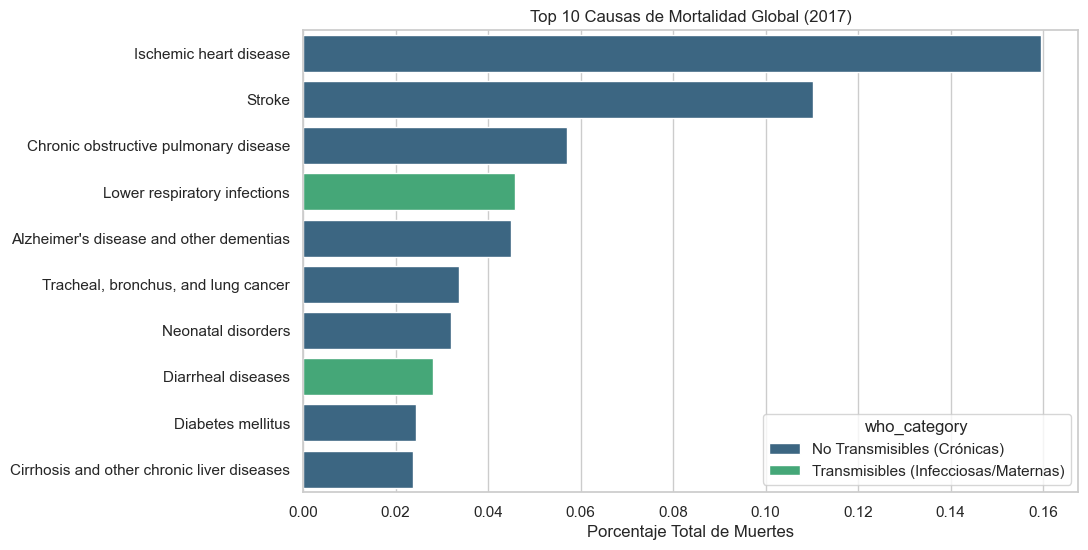

In [3]:
top_10 = df.nlargest(10, 'pct_deaths_2017')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='pct_deaths_2017', y='cause', hue='who_category', dodge=False, palette='viridis')
plt.title('Top 10 Causas de Mortalidad Global (2017)')
plt.xlabel('Porcentaje Total de Muertes')
plt.ylabel('')
plt.show()

## 2. Matriz de Riesgo y Transición Epidemiológica
Al cruzar el crecimiento anual con el volumen de muertes, identificamos el comportamiento dinámico de las enfermedades. El eje X separa el crecimiento positivo (riesgo futuro) del negativo (control médico).

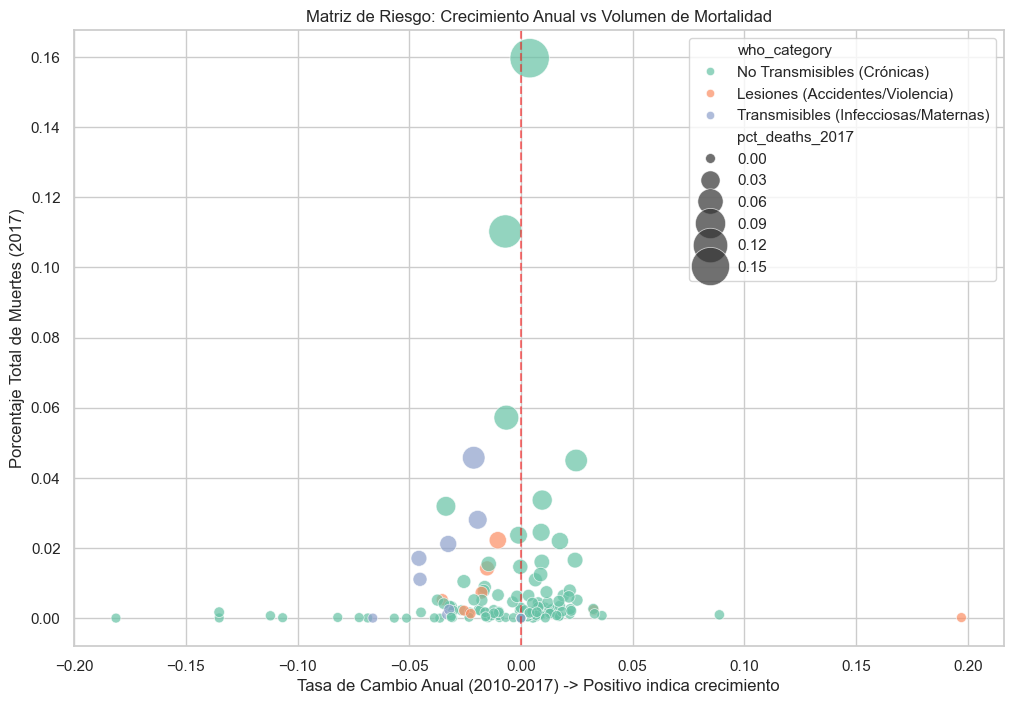

In [4]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, x='annual_change_2010_2017', y='pct_deaths_2017',
    hue='who_category', size='pct_deaths_2017', sizes=(50, 800), alpha=0.7, palette='Set2'
)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Matriz de Riesgo: Crecimiento Anual vs Volumen de Mortalidad')
plt.xlabel('Tasa de Cambio Anual (2010-2017) -> Positivo indica crecimiento')
plt.ylabel('Porcentaje Total de Muertes (2017)')
plt.show()

## Conclusión Crítica (Análisis Multivariado)

A partir del cruce de datos y las visualizaciones generadas, se evidencia un fenómeno demográfico conocido como **Transición Epidemiológica**:
1. **El éxito sobre las infecciones:** Las causas catalogadas por la OMS como *Transmisibles* (Infecciones, Tuberculosis, VIH) se agrupan casi en su totalidad en el lado izquierdo de la Matriz de Riesgo (tasas de cambio negativas). Esto indica que, aunque siguen causando muertes, están en declive sostenido.
2. **La carga de la modernidad:** Por el contrario, las enfermedades *No Transmisibles* (Crónicas como las cardiovasculares o neurológicas) dominan el ranking global de volumen y, alarmantemente, se ubican en el lado derecho de la matriz (crecimiento positivo). 

Este comportamiento confirma que los principales retos de mortalidad ya no radican en los virus, sino en enfermedades derivadas del envejecimiento poblacional y los hábitos de vida modernos.